In [ ]:
# ========================================
# Multiple Linear Regression on Housing Data
# ========================================
# G.Vinueza 20250902

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm



In [2]:

# Step 2: Load the dataset
df = pd.read_csv("Dataset_Housing.csv")

In [4]:
df.head()

,Size_sqft,Bedrooms,Age_years,Distance_to_city_center_km,Price_usd
0,1649,2,15,10.291044,"$253,187"
1,1458,3,29,4.285149,"$227,511"
2,1694,2,24,11.788937,"$234,821"
3,1956,2,2,12.803923,"$293,394"
4,1429,4,24,15.415256,"$227,207"


In [5]:
# Step 3: Data Cleaning
# Remove $ and commas from "Price_usd" and convert to numeric
df["Price_usd"] = (
    df["Price_usd"]
    .replace({'\$':'', ',':''}, regex=True)
    .astype(float)
)


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-826885320.py:5: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$':'', ',':''}, regex=True)


In [6]:
df.head()

,Size_sqft,Bedrooms,Age_years,Distance_to_city_center_km,Price_usd
0,1649,2,15,10.291044,253187.0
1,1458,3,29,4.285149,227511.0
2,1694,2,24,11.788937,234821.0
3,1956,2,2,12.803923,293394.0
4,1429,4,24,15.415256,227207.0


   Size_sqft  Bedrooms  Age_years  Distance_to_city_center_km  Price_usd
0       1649         2         15                   10.291044   253187.0
1       1458         3         29                    4.285149   227511.0
2       1694         2         24                   11.788937   234821.0
3       1956         2          2                   12.803923   293394.0
4       1429         4         24                   15.415256   227207.0
         Size_sqft   Bedrooms  Age_years  Distance_to_city_center_km  \
count    80.000000  80.000000  80.000000                   80.000000   
mean   1462.400000   3.037500  14.875000                   10.232160   
std     287.193165   0.833534   9.561758                    5.441579   
min     714.000000   2.000000   0.000000                    0.000000   
25%    1303.500000   2.000000   5.000000                    6.404653   
50%    1461.500000   3.000000  15.500000                   10.306222   
75%    1652.250000   4.000000  23.000000                  

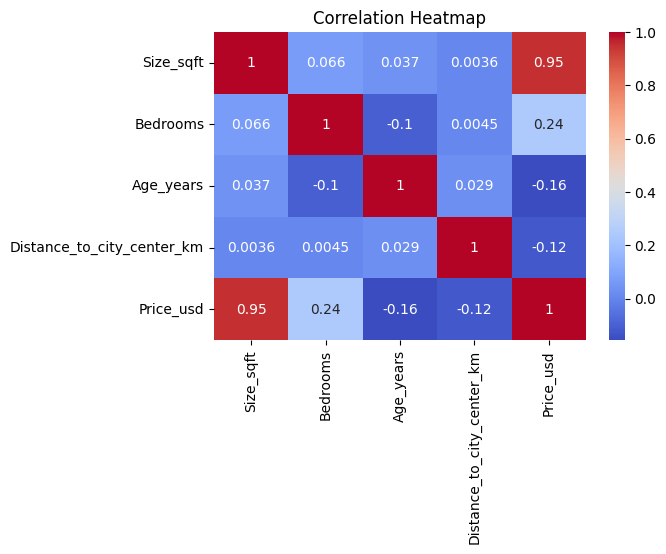

In [7]:
# Step 4: Exploratory Data Analysis (EDA)
print(df.head())          # Look at first rows
print(df.describe())      # Summary statistics
print(df.isnull().sum())  # Check missing values

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [8]:
# Step 5: Define features and target
X = df[["Size_sqft", "Bedrooms", "Age_years", "Distance_to_city_center_km"]]  # Independent variables
y = df["Price_usd"]  # Dependent variable

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Make predictions
y_pred = model.predict(X_test)

# Step 9: Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Step 10: Show coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)



Mean Squared Error: 56289947.543503895
R2 Score: 0.9648672099074889
                      Feature  Coefficient
0                   Size_sqft   145.689275
1                    Bedrooms  9163.031615
2                   Age_years  -788.797482
3  Distance_to_city_center_km -1075.727511


In [9]:
# Step 11: Statsmodels for P-values and F-statistic
X_sm = sm.add_constant(X)  # Add intercept
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

# Notes for students:
# - Each coefficient shows how much the house price changes
#   when that variable increases by 1 unit (holding others constant).
# - P-values tell us if a variable is statistically significant (usually < 0.05).
# - The F-statistic tests if the overall model is significant.
# - R2 shows how much of the variation in price is explained by the features.

                            OLS Regression Results                            
Dep. Variable:              Price_usd   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     637.4
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           4.72e-57
Time:                        01:07:49   Log-Likelihood:                -828.44
No. Observations:                  80   AIC:                             1667.
Df Residuals:                      75   BIC:                             1679.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               